In [1]:
import matplotlib.pyplot as plt
import torch

import sys
sys.path.append('..')
from src.dna import Genes, GenePool

In [2]:
from src.cuda.evolve_gpu import evaluate
g = GenePool.load('../genes/current-large_pop.pt', device=0)
scores, _ = evaluate(g, torch.arange(g.population, device=0), 50, 10)

	Evaluating... (35.83s)


In [7]:
import numpy as np
scores = np.array(scores)
top_scores = np.flip(np.argsort(scores))
for i in range(10):
    print(top_scores[i], scores[top_scores[i]])

260 1.6564998626708984
937 1.6429998874664307
20 1.6304999589920044
951 1.625
679 1.6019999980926514
776 1.5999999046325684
192 1.5950000286102295
754 1.5834999084472656
73 1.5814999341964722
57 1.5794999599456787


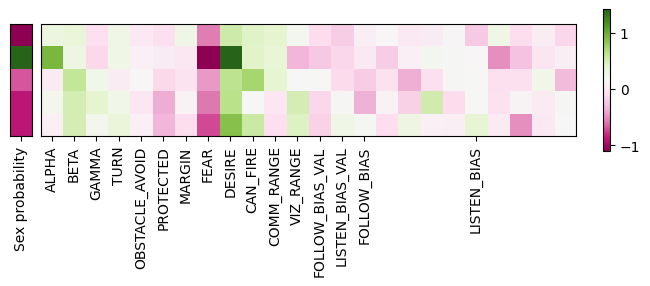

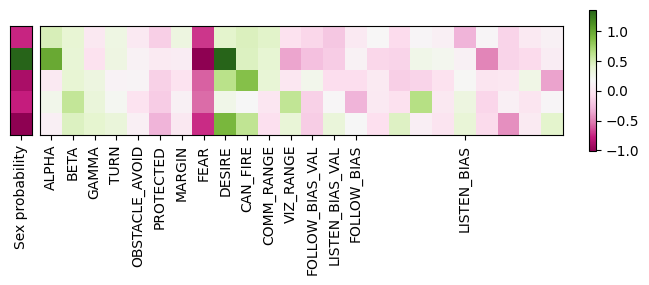

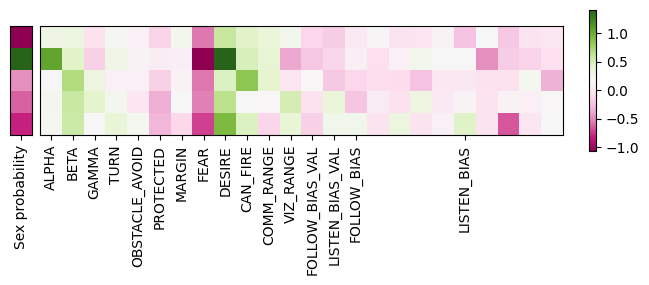

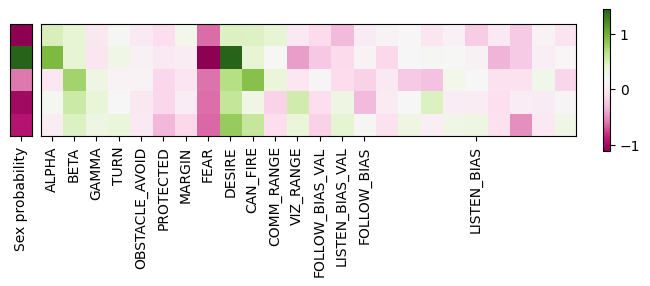

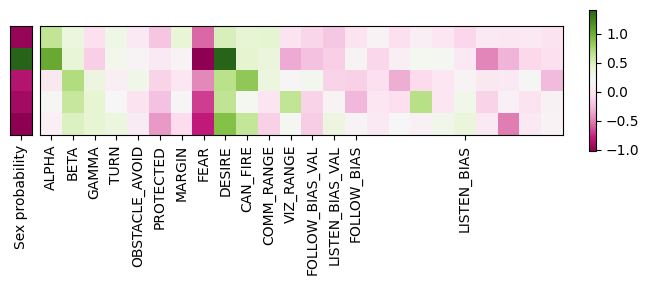

In [15]:
g = GenePool.load('../genes/current-large_pop.pt')

for i in top_scores[:5]:
    genes = g.genes[i]
    meta = g.meta_genes[i]

    fig, (ax1,ax2) = plt.subplots(
        1,2,
        sharey=True,
        layout='constrained',
        gridspec_kw={'width_ratios': [1, genes.shape[1]]}
    )
    im = ax2.imshow(genes, cmap='PiYG')
    ax2.set_xticks([gene._value_ for gene in list(Genes)[:-1]])
    ax2.set_xticklabels([gene._name_ for gene in list(Genes)[:-1]], rotation=90)
    ax2.set_yticks([])

    cbar = fig.colorbar(im, ax=ax2, shrink=0.3)

    ax1.imshow(meta.unsqueeze(-1), cmap='PiYG')
    ax1.set_xticks([0])
    ax1.set_xticklabels(['Sex probability'], rotation=90)

    plt.show()

In [4]:
list(Genes)[0].__dict__

{'_value_': 0,
 '_name_': 'ALPHA',
 '__objclass__': <enum 'Genes'>,
 '_sort_order_': 0}